In [1]:
#to check if an sms is spam or not using machine learning and deep learning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow_hub as hub

In [2]:
#loading the dataset
df = pd.read_csv('/content/spam.csv', encoding='latin-1')
df.head()


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
columns_to_drop = ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
if existing_columns_to_drop:
    df = df.drop(existing_columns_to_drop, axis=1)

df = df.rename(columns= {'v1': 'label', 'v2': 'text'})
df['label_Enc'] = df['label'].map({'ham': 0, 'spam': 1})
df.head()

,label,text,label_Enc
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [16]:
#spliting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    df['text'],
    df['label_Enc'], # Changed 'label' to 'label_Enc'
    test_size=0.2,
    random_state=42
)

#converting to numpy arrays
X_train_np = np.array(X_train)
X_test_np = np.array(X_test)
y_train_np = np.array(y_train)
y_test_np = np.array(y_test)

In [17]:
#stats of the data
#average no of words in the data
avg_words_len = round(sum([len(i.split())
for i in df['text']]) / len(df['text']))

total_word_length = len(set(" ". join(df['text']).split()))

#total  no of training samples
print(f"Data has been loaded.  Total no of trainning samples.{len(X_train_np)}")

#total avg no of messages
print(f"no of average words in messsages: {avg_words_len}")

#approx word length
print(f"no of words in the dictionary: {total_word_length}")

Data has been loaded.  Total no of trainning samples.4457
no of average words in messsages: 16
no of words in the dictionary: 15686


In [29]:
#compile and fit function
def compile_and_fit(model, epoch = 5):
  model.compile(
      optimizer = 'adam',
      loss = 'binary_crossentropy',
      metrics = ['accuracy']
  )

  history = model.fit(
      X_train_np,
      y_train_np,
      epochs = epoch,
      validation_data = (X_test_np, y_test_np)
  )

  return history

def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch
  plt.figure()
  plt.xlabel('Epoch')
  plt.ylabel('Mean Abs Error')
  plt.plot(hist['epoch'], hist['accuracy'], label='Train Error')
  plt.plot(hist['epoch'], hist['val_accuracy'], label='Val Error')
  plt.ylim([0, 1])
  plt.legend()
  plt.show()
  plt.figure()


def get_metrics(model, X, y):
  y_preds = model.predict(X)
  y_preds = np.round(y_preds)
  return {
      'accuracy': accuracy_score(y, y_preds),
      'precision': precision_score(y, y_preds),
      'recall': recall_score(y, y_preds),
      'f1': f1_score(y, y_preds)
  }



In [30]:
#test vectorisation layer
from tensorflow.keras.layers import TextVectorization
text_vectoriser = TextVectorization(
    max_tokens = total_word_length,
    standardize = 'lower_and_strip_punctuation',
    output_mode = 'int',
    output_sequence_length = avg_words_len
)
text_vectoriser.adapt(X_train_np)

In [31]:
#model 1
input_layer = layers.Input(shape=(1,), dtype= tf.string)

x = text_vectoriser(input_layer)
x = layers.Embedding(input_dim= total_word_length, output_dim= 128)(x)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

#eval of model 1
model_1 = keras.Model(input_layer, output_layer)

hist_1 = compile_and_fit(model_1)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.8999 - loss: 0.3014 - val_accuracy: 0.9587 - val_loss: 0.1577
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9758 - loss: 0.1014 - val_accuracy: 0.9731 - val_loss: 0.0836
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9863 - loss: 0.0493 - val_accuracy: 0.9767 - val_loss: 0.0738
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9935 - loss: 0.0300 - val_accuracy: 0.9785 - val_loss: 0.0664
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9962 - loss: 0.0204 - val_accuracy: 0.9785 - val_loss: 0.0631


In [32]:
#model 2: bidirectional lstm
input_layer = layers.Input(shape = (1,), dtype = tf.string)

x = text_vectoriser(input_layer)
x = layers.Embedding(input_dim=total_word_length, output_dim=128)(x)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64))(x)
x = layers.Flatten()(x
                    )
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu')(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

#eval
model_2 = keras.Model(input_layer, output_layer)
hist_2 = compile_and_fit(model_2)


Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 76ms/step - accuracy: 0.9426 - loss: 0.1728 - val_accuracy: 0.9758 - val_loss: 0.0837
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.9906 - loss: 0.0369 - val_accuracy: 0.9776 - val_loss: 0.0894
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.9964 - loss: 0.0160 - val_accuracy: 0.9785 - val_loss: 0.0761
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.9989 - loss: 0.0054 - val_accuracy: 0.9803 - val_loss: 0.0972
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 70ms/step - accuracy: 0.9987 - loss: 0.0025 - val_accuracy: 0.9803 - val_loss: 0.1198


In [36]:
use_layer = hub.KerasLayer(
    "https://tfhub.dev/google/universal-sentence-encoder/4",
    trainable=False,
    input_shape=[],
    dtype=tf.string,
    name='USE'
)
# Corrected input shape to () for scalar string input
input_layer = layers.Input(shape=(), dtype=tf.string)

# Wrap the use_layer call in a Lambda layer to handle tf.function binding
embedding = layers.Lambda(lambda x: use_layer(x), output_shape=(512,))(input_layer)
x = layers.Dense(128, activation='relu')(embedding)
x = layers.Dropout(0.2)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model_3 = keras.Model(input_layer, output)
hist_3 = compile_and_fit(model_3)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9340 - loss: 0.2379 - val_accuracy: 0.9758 - val_loss: 0.0846
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9816 - loss: 0.0650 - val_accuracy: 0.9812 - val_loss: 0.0597
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9870 - loss: 0.0472 - val_accuracy: 0.9839 - val_loss: 0.0537
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9904 - loss: 0.0376 - val_accuracy: 0.9830 - val_loss: 0.0514
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9910 - loss: 0.0316 - val_accuracy: 0.9821 - val_loss: 0.0509


In [38]:
#report card
results = {
    'Dense Embedding: ' : get_metrics(model_1, X_test_np, y_test_np),
    'BI-LSTM: ': get_metrics(model_2, X_test_np, y_test_np),
    'USE:' :get_metrics(model_3, X_test_np, y_test_np)
}
results_df = pd.DataFrame(results).transpose()
print("PERFORMANCE TABLE")
print(results_df)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
PERFORMANCE TABLE
                   accuracy  precision    recall        f1
Dense Embedding:   0.978475   0.943262  0.892617  0.917241
BI-LSTM:           0.980269   0.963504  0.885906  0.923077
USE:               0.982063   0.944828  0.919463  0.931973


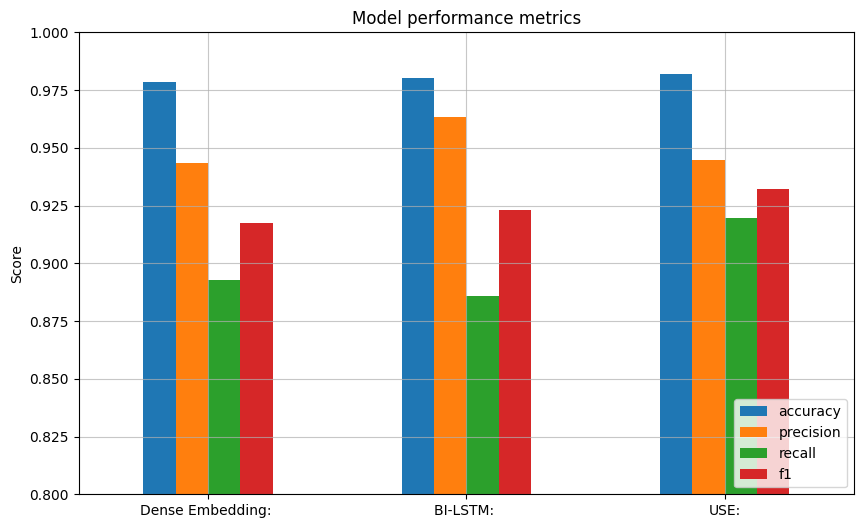

In [41]:
results_df.plot(kind = 'bar', figsize=(10, 6))
plt.title("Model performance metrics")
plt.ylabel('Score')
plt.ylim(0.8, 1.0)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle = '-', alpha= 0.7)
plt.grid(axis='x', linestyle = '-', alpha= 0.7)
plt.show()


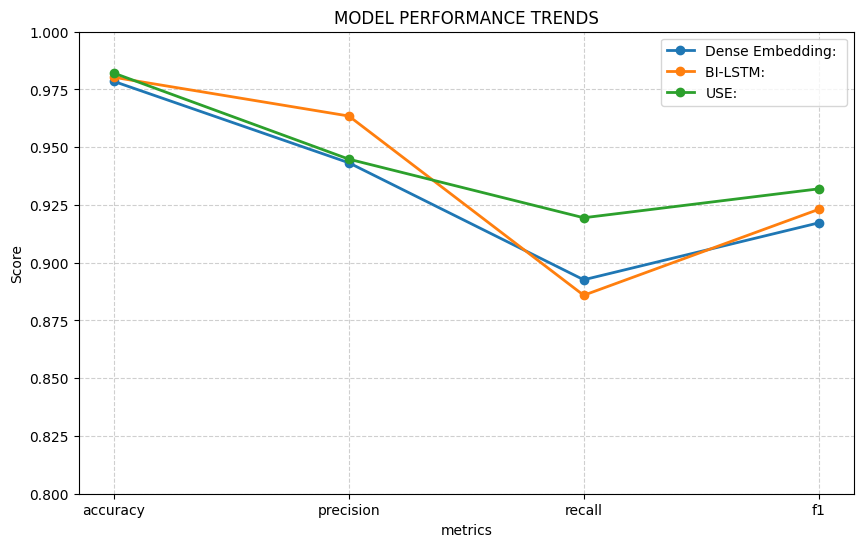

In [44]:
#line graph
plt.figure(figsize = (10, 6))

for model_name in results_df.index:
  plt.plot(
      results_df.columns,
      results_df.loc[model_name],
      marker = 'o',
      label = model_name,
      linewidth = 2

  )
plt.title('MODEL PERFORMANCE TRENDS')
plt.ylabel('Score')
plt.xlabel('metrics')
plt.ylim(0.8, 1.0)
plt.grid(True, linestyle = '--', alpha = 0.6)
plt.legend()
plt.show()